# Intern Performance Prediction using Machine Learning

## Objective

The purpose of this project is to predict intern performance based on attendance, task submissions, and mentor feedback using a machine learning model.

## Tools Used

- Python
- Pandas
- Matplotlib
- Scikit-learn
- Jupyter Notebook

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

## Create Dataset

In [3]:
records=[]

for i in range(100):

    attendance=random.randint(50,100)

    tasks=random.randint(0,20)

    feedback=random.randint(1,10)

    if attendance>=75 and tasks>=12 and feedback>=6:
        performance="Successful"
    else:
        performance="Needs Improvement"

    records.append([
        attendance,
        tasks,
        feedback,
        performance
    ])

df=pd.DataFrame(records,
columns=[
    "Attendance",
    "Task_Submissions",
    "Feedback",
    "Performance"
])

df.to_csv("intern_data.csv",index=False)

df.head()

,Attendance,Task_Submissions,Feedback,Performance
0,55,20,9,Needs Improvement
1,81,17,8,Successful
2,98,5,8,Needs Improvement
3,94,2,4,Needs Improvement
4,85,7,8,Needs Improvement


## Load Dataset

In [4]:
data=pd.read_csv("intern_data.csv")

data.head()

,Attendance,Task_Submissions,Feedback,Performance
0,55,20,9,Needs Improvement
1,81,17,8,Successful
2,98,5,8,Needs Improvement
3,94,2,4,Needs Improvement
4,85,7,8,Needs Improvement


## Explore Dataset

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Attendance        100 non-null    int64
 1   Task_Submissions  100 non-null    int64
 2   Feedback          100 non-null    int64
 3   Performance       100 non-null    str  
dtypes: int64(3), str(1)
memory usage: 3.3 KB


data.describe()

## Data Preprocessing

In [7]:
data["Performance"]=data["Performance"].map({
    "Successful":1,
    "Needs Improvement":0
})

data.head()

,Attendance,Task_Submissions,Feedback,Performance
0,55,20,9,0
1,81,17,8,1
2,98,5,8,0
3,94,2,4,0
4,85,7,8,0


In [8]:
X=data[[
    "Attendance",
    "Task_Submissions",
    "Feedback"
]]

y=data["Performance"]

## Split Dataset

In [9]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train Machine Learning Model

In [10]:
model=DecisionTreeClassifier()

In [11]:
model.fit(
    X_train,
    y_train
)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## Prediction

In [12]:
prediction=model.predict(X_test)

In [13]:
accuracy=accuracy_score(
    y_test,
    prediction
)

print("Accuracy =",accuracy)

Accuracy = 1.0


In [16]:
new_intern=[[90,18,8]]

result=model.predict(new_intern)

if result[0]==1:
    print("Successful")
else:
    print("Needs Improvement")

Successful


C:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## Data Visualization

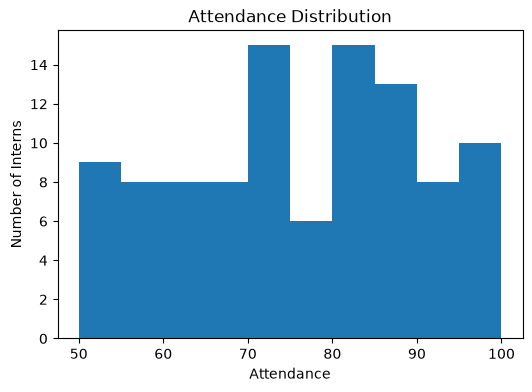

In [17]:
plt.figure(figsize=(6,4))

plt.hist(data["Attendance"])

plt.title("Attendance Distribution")

plt.xlabel("Attendance")

plt.ylabel("Number of Interns")

plt.show()

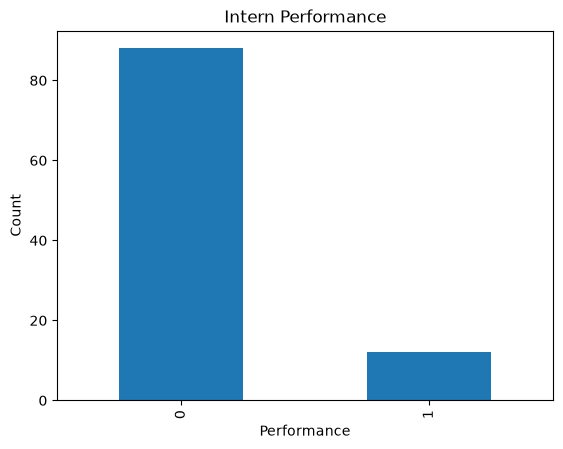

In [18]:
data["Performance"].value_counts().plot(
kind="bar"
)

plt.title("Intern Performance")

plt.xlabel("Performance")

plt.ylabel("Count")

plt.show()

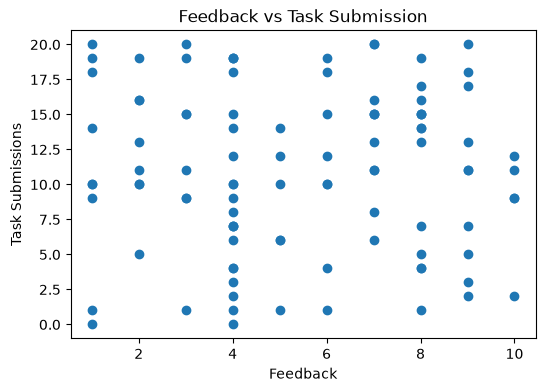

In [19]:
plt.figure(figsize=(6,4))

plt.scatter(
    data["Feedback"],
    data["Task_Submissions"]
)

plt.title("Feedback vs Task Submission")

plt.xlabel("Feedback")

plt.ylabel("Task Submissions")

plt.show()

# Conclusion

- The machine learning model predicts intern performance based on attendance, task submissions, and feedback.
- Higher attendance generally leads to better performance.
- Interns who submit more tasks are more likely to succeed.
- Positive mentor feedback is associated with higher success.
- Mentors can use these insights to identify interns who may need additional guidance and support.